In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nav_history = pd.read_csv("../data/processed/02_nav_history_clean.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
portfolio_holdings = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")
fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")

In [2]:
nav_history["date"] = pd.to_datetime(nav_history["date"])
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [4]:
var_results = []

for fund in nav_history["amfi_code"].unique():

    df = nav_history[
        nav_history["amfi_code"] == fund
    ].copy()

    df = df.sort_values("date")

    df["daily_return"] = df["nav"].pct_change()

    returns = df["daily_return"].dropna()

    if len(returns) > 0:

        var_95 = np.percentile(
            returns,
            5
        )

        cvar_95 = returns[
            returns <= var_95
        ].mean()

        var_results.append(
            [
                fund,
                var_95,
                cvar_95
            ]
        )

var_cvar_report = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar_report.head()
var_cvar_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

In [5]:
top5_funds = (
    performance
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(5)["amfi_code"]
    .tolist()
)

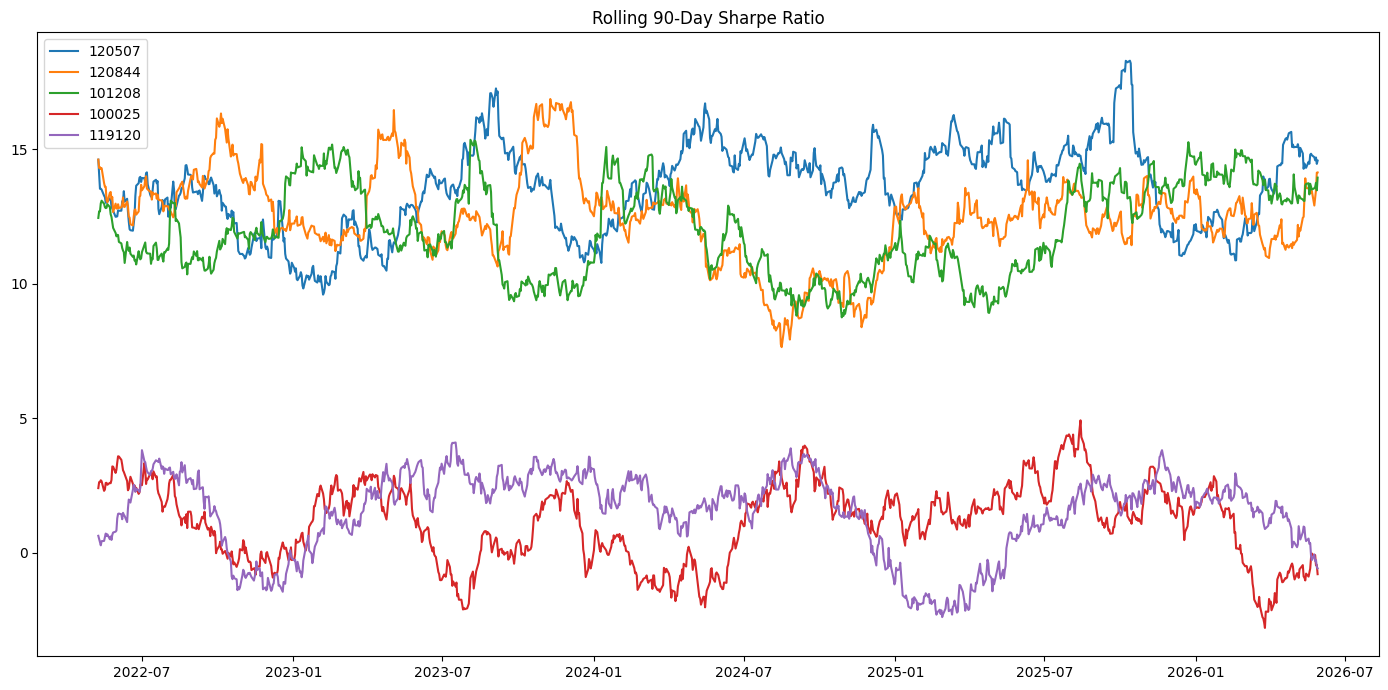

<Figure size 640x480 with 0 Axes>

In [7]:
plt.figure(figsize=(14,7))

for fund in top5_funds:

    df = nav_history[
        nav_history["amfi_code"] == fund
    ].copy()

    df = df.sort_values("date")

    df["daily_return"] = (
        df["nav"].pct_change()
    )

    rolling_sharpe = (
        df["daily_return"]
        .rolling(90)
        .mean()
        /
        df["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        df["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.legend()

plt.tight_layout()

plt.show()

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

In [8]:
transactions["cohort_year"] = (
    transactions
    .groupby("investor_id")
    ["transaction_date"]
    .transform("min")
    .dt.year
)

cohort_analysis = (
    transactions
    .groupby("cohort_year")
    .agg(
        avg_sip_amount=(
            "amount_inr",
            "mean"
        ),
        total_invested=(
            "amount_inr",
            "sum"
        )
    )
)

cohort_analysis

,avg_sip_amount,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [9]:
top_fund_pref = (
    transactions
    .groupby(
        ["cohort_year","amfi_code"]
    )
    .size()
    .reset_index(name="count")
)

top_fund_pref = (
    top_fund_pref
    .sort_values(
        ["cohort_year","count"],
        ascending=False
    )
    .groupby("cohort_year")
    .head(1)
)

top_fund_pref

,cohort_year,amfi_code,count
62,2025,119599,12
35,2024,148568,874


In [18]:
sip_txn = transactions[
    transactions["transaction_type"] == "Sip"
].copy()
sip_txn = sip_txn.sort_values(
    ["investor_id","transaction_date"]
)

sip_txn["gap_days"] = (
    sip_txn
    .groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

sip_continuity = (
    sip_txn
    .groupby("investor_id")
    .agg(
        avg_gap_days=(
            "gap_days",
            "mean"
        ),
        sip_count=(
            "transaction_date",
            "count"
        )
    )
)

sip_continuity = sip_continuity[
    sip_continuity["sip_count"] >= 6
]

sip_continuity["at_risk"] = (
    sip_continuity["avg_gap_days"] > 35
)

sip_continuity.head()

,avg_gap_days,sip_count,at_risk
investor_id,,,
INV000004,85.400000,6,True
INV000008,70.400000,6,True
INV000010,64.800000,6,True
INV000011,40.166667,7,True
INV000012,57.000000,8,True


In [19]:
def recommend_funds(risk_level):

    df = performance[
        performance["risk_grade"]
        == risk_level
    ]

    return (
        df
        .sort_values(
            "sharpe_ratio",
            ascending=False
        )
        .head(3)[
            [
                "scheme_name",
                "sharpe_ratio",
                "risk_grade"
            ]
        ]
    )

In [20]:
recommend_funds("High")

,scheme_name,sharpe_ratio,risk_grade
21,Kotak Emerging Equity Fund - Regular - Growth,0.96,High
12,ICICI Pru Midcap Fund - Regular - Growth,0.95,High
38,DSP Midcap Fund - Regular - Growth,0.90,High


In [22]:
portfolio_holdings["weight_sq"] = (
    portfolio_holdings["weight_pct"]
    / 100
) ** 2

hhi_df = (
    portfolio_holdings
    .groupby("amfi_code")
    ["weight_sq"]
    .sum()
    .reset_index()
)

hhi_df.columns = [
    "amfi_code",
    "HHI"
]

hhi_df.sort_values(
    "HHI",
    ascending=False
).head()

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298


### Insight 1
Funds with the most negative VaR and CVaR values exhibited the highest downside risk and were more vulnerable during periods of market stress.

### Insight 2
The highest Sharpe Ratio funds maintained superior risk-adjusted returns even when evaluated using rolling 90-day windows.

### Insight 3
Recent investor cohorts contributed the largest investment volumes, indicating increasing participation in mutual fund investing.

### Insight 4
A significant proportion of SIP investors maintained monthly investing discipline, while investors with average gaps exceeding 35 days were classified as at-risk.

### Insight 5
Funds with higher HHI scores were more concentrated in a limited number of sectors, potentially increasing portfolio-specific risk.